In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")


In [2]:
df = pd.read_csv("../data/processed/news_labeled.csv")
df.head()


,title,text,subject,date,label
0,Ben Stein Calls Out 9th Circuit Court: Committ...,"21st Century Wire says Ben Stein, reputable pr...",US_News,"February 13, 2017",0
1,Trump drops Steve Bannon from National Securit...,WASHINGTON (Reuters) - U.S. President Donald T...,politicsNews,"April 5, 2017",1
2,Puerto Rico expects U.S. to lift Jones Act shi...,(Reuters) - Puerto Rico Governor Ricardo Rosse...,politicsNews,"September 27, 2017",1
3,OOPS: Trump Just Accidentally Confirmed He Le...,"On Monday, Donald Trump once again embarrassed...",News,"May 22, 2017",0
4,Donald Trump heads for Scotland to reopen a go...,"GLASGOW, Scotland (Reuters) - Most U.S. presid...",politicsNews,"June 24, 2016",1


In [3]:
df.info()
df.isnull().sum()


<class 'pandas.DataFrame'>
RangeIndex: 44898 entries, 0 to 44897
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   title    44898 non-null  str  
 1   text     44898 non-null  str  
 2   subject  44898 non-null  str  
 3   date     44898 non-null  str  
 4   label    44898 non-null  int64
dtypes: int64(1), str(4)
memory usage: 112.3 MB


title      0
text       0
subject    0
date       0
label      0
dtype: int64

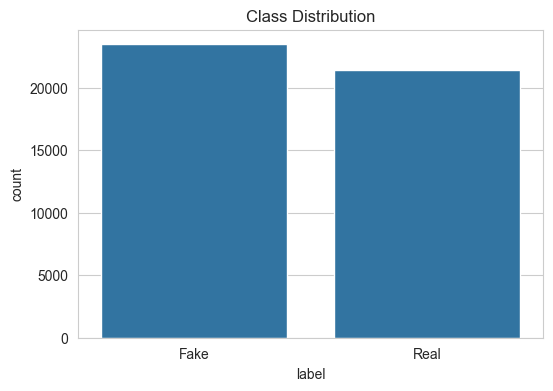

In [4]:
plt.figure(figsize=(6,4))
sns.countplot(x="label", data=df)
plt.xticks([0,1], ["Fake", "Real"])
plt.title("Class Distribution")
plt.show()


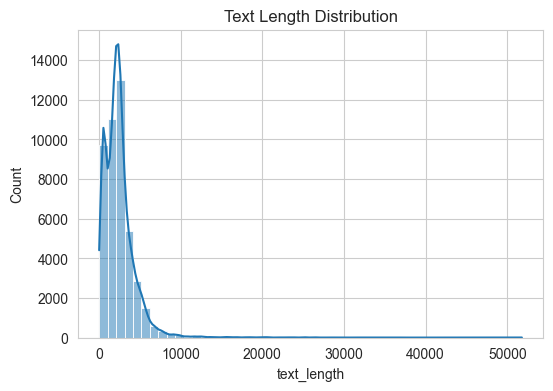

In [5]:
df["text_length"] = df["text"].apply(len)

plt.figure(figsize=(6,4))
sns.histplot(df["text_length"], bins=50, kde=True)
plt.title("Text Length Distribution")
plt.show()


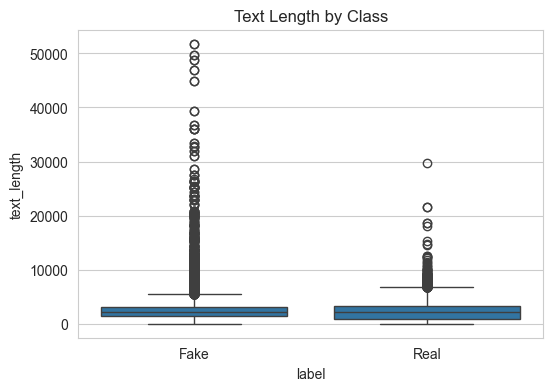

In [6]:
plt.figure(figsize=(6,4))
sns.boxplot(x="label", y="text_length", data=df)
plt.xticks([0,1], ["Fake", "Real"])
plt.title("Text Length by Class")
plt.show()


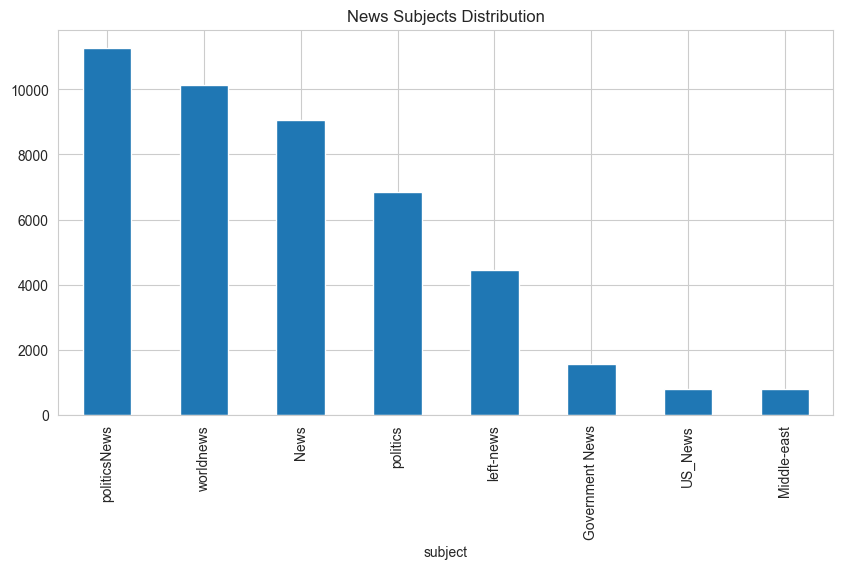

In [7]:
plt.figure(figsize=(10,5))
df["subject"].value_counts().plot(kind="bar")
plt.title("News Subjects Distribution")
plt.show()


In [8]:
from collections import Counter
import re

def get_top_words(text_series, n=20):
    words = []
    for text in text_series:
        text = re.sub(r"[^a-zA-Z]", " ", text.lower())
        words.extend(text.split())
    return Counter(words).most_common(n)

fake_words = get_top_words(df[df["label"] == 0]["text"])
real_words = get_top_words(df[df["label"] == 1]["text"])

print("Top Fake News Words:", fake_words)
print("Top Real News Words:", real_words)


Top Fake News Words: [('the', 544568), ('to', 290888), ('of', 236744), ('and', 227371), ('a', 215261), ('in', 171444), ('that', 151790), ('s', 142571), ('is', 111283), ('for', 93542), ('it', 83700), ('on', 83666), ('trump', 79939), ('he', 79130), ('was', 67865), ('with', 63441), ('this', 58597), ('his', 58375), ('as', 57903), ('be', 49287)]
Top Real News Words: [('the', 482469), ('to', 245734), ('of', 205277), ('a', 198664), ('and', 182081), ('in', 181652), ('s', 142720), ('on', 108598), ('said', 99062), ('that', 88237), ('for', 79897), ('is', 55494), ('trump', 54702), ('with', 54504), ('he', 54371), ('it', 49592), ('by', 47949), ('was', 47946), ('as', 47333), ('has', 46246)]


- Dataset contains 44,919 news articles.
- Classes are nearly balanced.
- Text length varies significantly between fake and real news.
- Certain subjects dominate the dataset.
- Word usage patterns differ between classes.
